# Interactive Simulation Exploration

This notebook uses vivarium's `InteractiveContext` to set up the
NIH US CVD simulation, step through time, and explore the population
table — focusing on **LDL-C exposure** and the related
**MI and ischemic stroke** disease state columns.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from vivarium import InteractiveContext

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Initialize the Simulation

Create an `InteractiveContext` with a small population so we can
inspect individual simulants. We use 2,000 simulants and the
USA-level artifact.

In [2]:
MODEL_SPEC = '../src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd.yaml'
ARTIFACT = str(Path('../src/vivarium_nih_us_cvd/artifacts/united_states_of_america.hdf').resolve())

sim = InteractiveContext(
    MODEL_SPEC,
    configuration={
        'input_data': {'artifact_path': ARTIFACT},
        'population': {'population_size': 1_000},
    },
    setup=True,
)

print(f'Current time: {sim.current_time}')
pop = sim.get_population()
print(f'Population size: {len(pop)}')
print(f'Columns ({len(pop.columns)}): {sorted(pop.columns.tolist())}')

2026-04-07 09:35:32.993 | INFO     | simulation_1-artifact_manager:78 - Running simulation from artifact located at /home/abie/vivarium_nih_us_cvd/src/vivarium_nih_us_cvd/artifacts/united_states_of_america.hdf.


2026-04-07 09:35:32.994 | INFO     | simulation_1-artifact_manager:79 - Artifact base filter terms are ['draw == 0'].


2026-04-07 09:35:32.995 | INFO     | simulation_1-artifact_manager:80 - Artifact additional filter terms are None.


2026-04-07 09:35:48.101 | WARNING  | simulation_1-resource_manager:176 - Resource stream.ischemic_stroke_initial_states is not produced by any component but is needed to compute (column.ischemic_stroke).


2026-04-07 09:35:48.103 | WARNING  | simulation_1-resource_manager:176 - Resource stream.ischemic_heart_disease_and_heart_failure_initial_states is not produced by any component but is needed to compute (column.ischemic_heart_disease_and_heart_failure).


Current time: 2021-01-01 00:00:00
Population size: 1000
Columns (67): ['acute_ischemic_stroke_event_count', 'acute_ischemic_stroke_event_time', 'acute_myocardial_infarction_and_heart_failure_event_count', 'acute_myocardial_infarction_and_heart_failure_event_time', 'acute_myocardial_infarction_event_count', 'acute_myocardial_infarction_event_time', 'age', 'alive', 'cause_of_death', 'chronic_ischemic_stroke_event_count', 'chronic_ischemic_stroke_event_time', 'discontinued_ldlc_medication', 'discontinued_sbp_medication', 'ensemble_propensity_risk_factor.high_body_mass_index_in_adults', 'ensemble_propensity_risk_factor.high_fasting_plasma_glucose', 'ensemble_propensity_risk_factor.high_ldl_cholesterol', 'ensemble_propensity_risk_factor.high_systolic_blood_pressure', 'entrance_time', 'exit_time', 'heart_failure_from_ischemic_heart_disease_event_count', 'heart_failure_from_ischemic_heart_disease_event_time', 'heart_failure_residual_event_count', 'heart_failure_residual_event_time', 'high_bod

In [3]:
%pip install pkg_resources

Looking in indexes: https://pypi.org/simple, https://artifactory.ihme.washington.edu/artifactory/api/pypi/pypi-shared/simple


ERROR: Could not find a version that satisfies the requirement pkg_resources (from versions: none)
ERROR: No matching distribution found for pkg_resources


Note: you may need to restart the kernel to use updated packages.


## 2. Initial Population Overview

Inspect demographics and disease state assignments at initialization
(before any time steps).

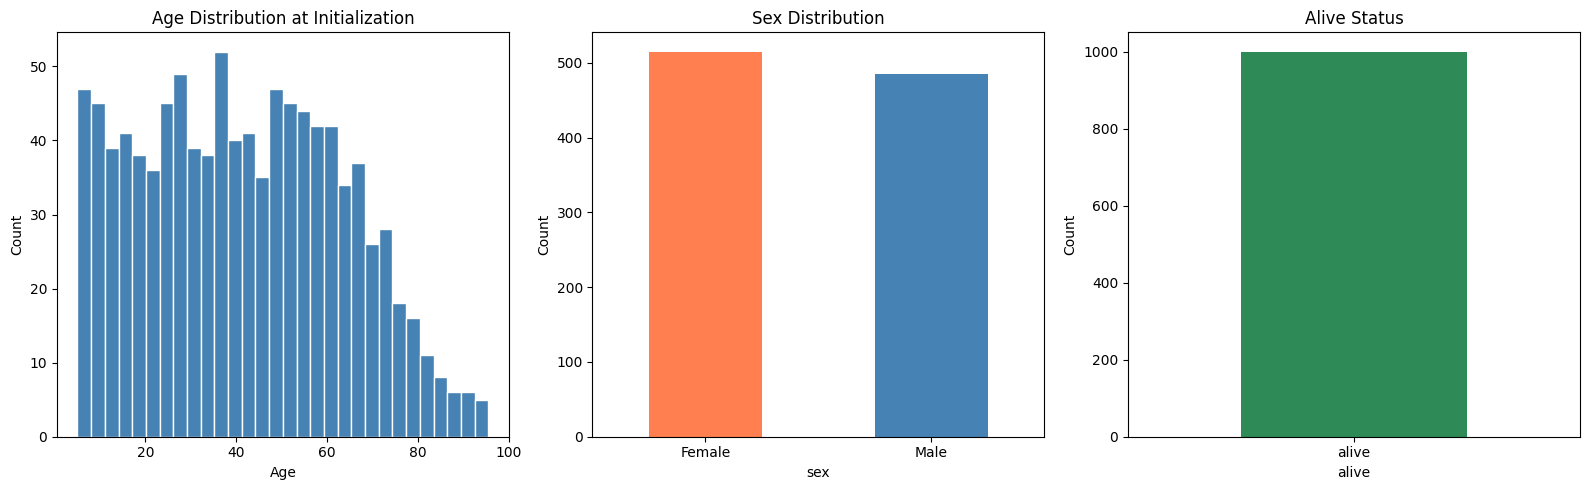

In [4]:
pop = sim.get_population()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(pop['age'], bins=30, edgecolor='white', color='steelblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution at Initialization')

# Sex
pop['sex'].value_counts().plot.bar(ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_title('Sex Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# Alive status
pop['alive'].value_counts().plot.bar(ax=axes[2], color='seagreen')
axes[2].set_title('Alive Status')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Initial Disease States

The simulation tracks two disease models:
- **Ischemic stroke**: susceptible, acute, chronic
- **IHD & heart failure**: susceptible, acute MI, post MI, HF from IHD,
  acute MI + HF, HF residual

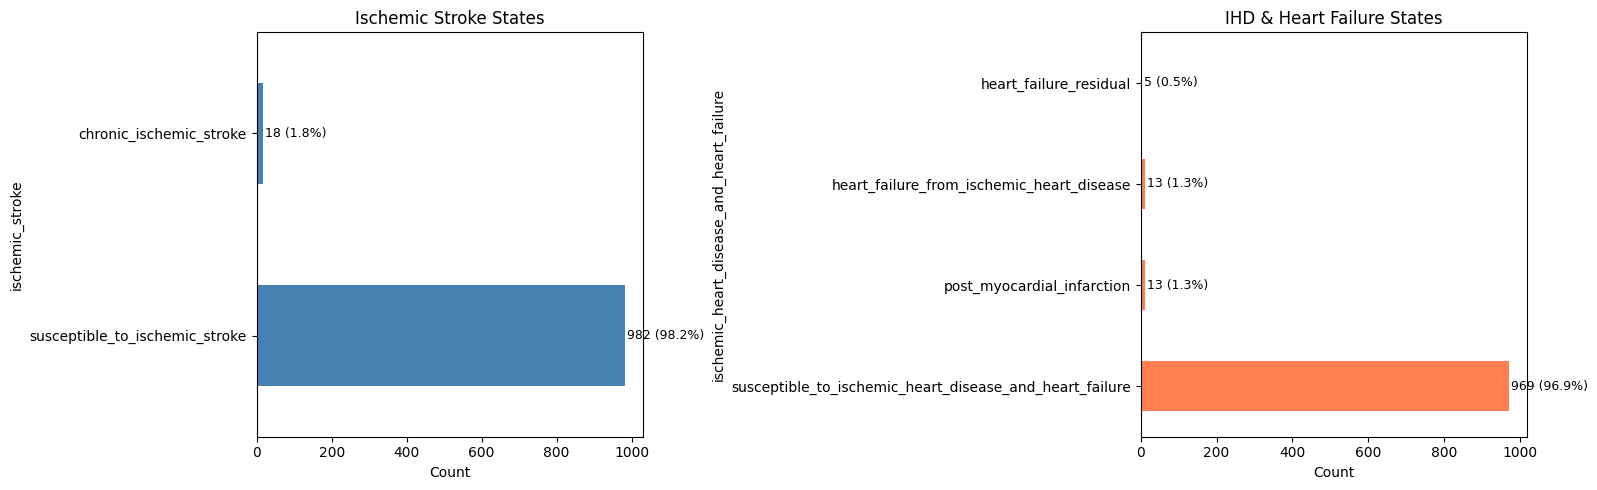

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ischemic stroke states
is_counts = pop['ischemic_stroke'].value_counts()
is_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Ischemic Stroke States')
axes[0].set_xlabel('Count')
for i, (state, count) in enumerate(is_counts.items()):
    axes[0].text(count + 5, i, f'{count} ({count/len(pop)*100:.1f}%)', va='center', fontsize=9)

# IHD & HF states
ihd_counts = pop['ischemic_heart_disease_and_heart_failure'].value_counts()
ihd_counts.plot.barh(ax=axes[1], color='coral')
axes[1].set_title('IHD & Heart Failure States')
axes[1].set_xlabel('Count')
for i, (state, count) in enumerate(ihd_counts.items()):
    axes[1].text(count + 5, i, f'{count} ({count/len(pop)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. LDL-C Exposure at Initialization

The model has several LDL-C related pipelines:
- `high_ldl_cholesterol.gbd_exposure` — raw GBD exposure (before medication)
- `high_ldl_cholesterol.exposure` — current exposure (after medication multiplier)
- `high_ldl_cholesterol.propensity` — individual propensity quantile (0 to 1)

And population table columns:
- `ldlc_medication` — current medication level
- `ldlc_medication_adherence` — adherence category
- `ldlc_multiplier` — medication effect multiplier on exposure

In [6]:
idx = pop.index

# Get LDL-C pipeline values
ldlc_gbd = sim.get_value('high_ldl_cholesterol.gbd_exposure')(idx)
ldlc_current = sim.get_value('high_ldl_cholesterol.exposure')(idx)
ldlc_propensity = sim.get_value('high_ldl_cholesterol.propensity')(idx)

# Build a summary dataframe
ldlc_df = pd.DataFrame({
    'age': pop['age'],
    'sex': pop['sex'],
    'gbd_exposure': ldlc_gbd,
    'current_exposure': ldlc_current,
    'propensity': ldlc_propensity,
    'medication': pop['ldlc_medication'],
    'adherence': pop['ldlc_medication_adherence'],
    'multiplier': pop['ldlc_multiplier'],
})

print('LDL-C summary stats:')
print(ldlc_df[['gbd_exposure', 'current_exposure', 'propensity', 'multiplier']].describe().round(2))
print(f"\nMedian GBD exposure: {ldlc_gbd.median():.2f} mmol/L")
print(f"Median current exposure: {ldlc_current.median():.2f} mmol/L")

LDL-C summary stats:
       gbd_exposure  current_exposure  propensity  multiplier
count       1000.00           1000.00     1000.00     1000.00
mean           2.23              2.20        0.52        1.04
std            1.59              1.57        0.29        0.12
min            0.00              0.00        0.00        1.00
25%            0.00              0.00        0.24        1.00
50%            2.46              2.41        0.55        1.00
75%            3.47              3.41        0.77        1.00
max            5.50              5.50        1.00        1.51

Median GBD exposure: 2.46 mmol/L
Median current exposure: 2.41 mmol/L


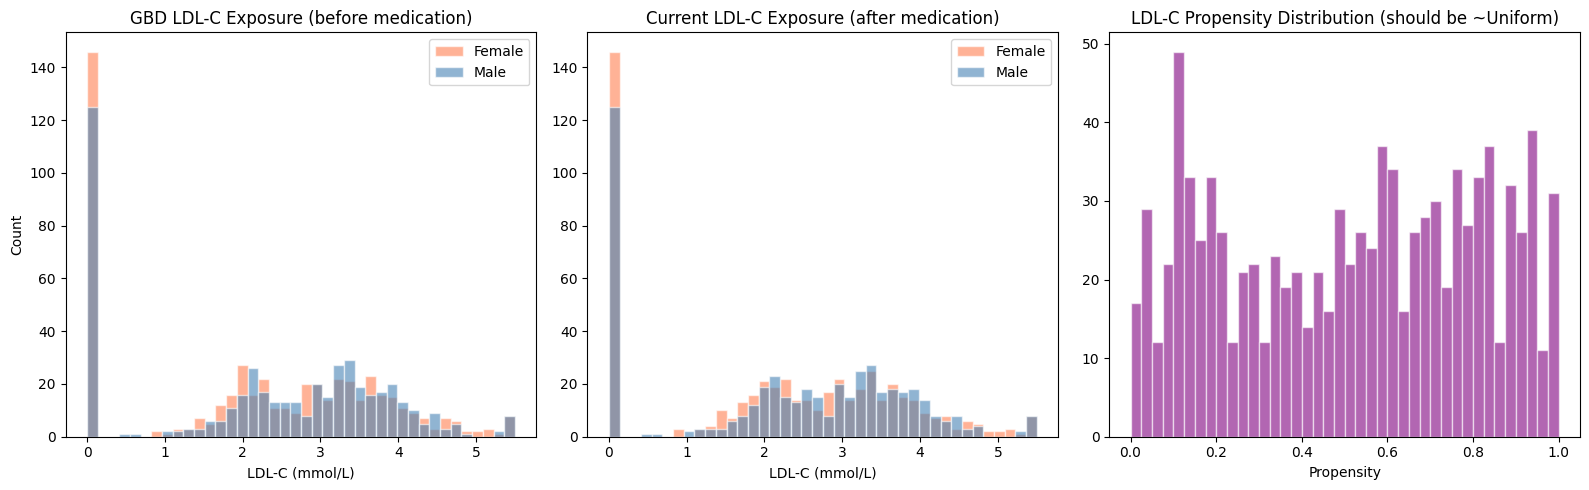

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GBD exposure distribution
for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
    vals = ldlc_df[ldlc_df['sex'] == sex]['gbd_exposure']
    axes[0].hist(vals, bins=40, alpha=0.6, color=color, label=sex, edgecolor='white')
axes[0].set_xlabel('LDL-C (mmol/L)')
axes[0].set_ylabel('Count')
axes[0].set_title('GBD LDL-C Exposure (before medication)')
axes[0].legend()

# Current exposure (after medication)
for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
    vals = ldlc_df[ldlc_df['sex'] == sex]['current_exposure']
    axes[1].hist(vals, bins=40, alpha=0.6, color=color, label=sex, edgecolor='white')
axes[1].set_xlabel('LDL-C (mmol/L)')
axes[1].set_title('Current LDL-C Exposure (after medication)')
axes[1].legend()

# Propensity distribution
axes[2].hist(ldlc_df['propensity'], bins=40, color='purple', alpha=0.6, edgecolor='white')
axes[2].set_xlabel('Propensity')
axes[2].set_title('LDL-C Propensity Distribution (should be ~Uniform)')

plt.tight_layout()
plt.show()

### 4.1 LDL-C Exposure by Age and Sex

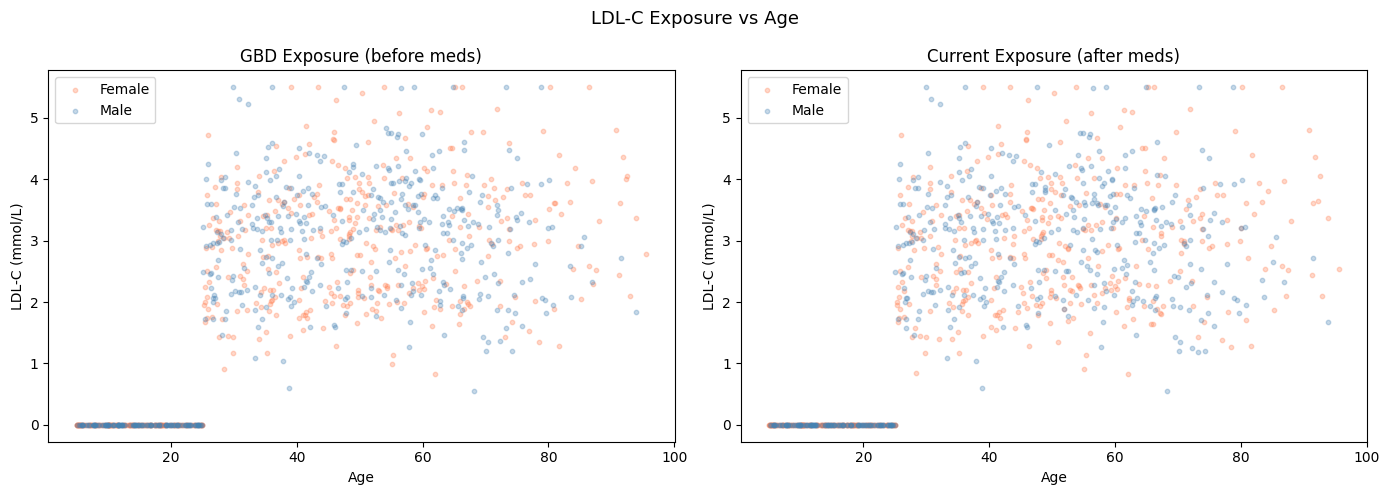

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'gbd_exposure', 'GBD Exposure (before meds)'),
    (axes[1], 'current_exposure', 'Current Exposure (after meds)'),
]:
    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        sub = ldlc_df[ldlc_df['sex'] == sex]
        ax.scatter(sub['age'], sub[col], alpha=0.3, s=10, color=color, label=sex)
    ax.set_xlabel('Age')
    ax.set_ylabel('LDL-C (mmol/L)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('LDL-C Exposure vs Age', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 LDL-C Medication Status

The medication column indicates whether a simulant is on no treatment,
low/med/high intensity statin therapy. The multiplier column shows the
resulting effect on LDL-C exposure.

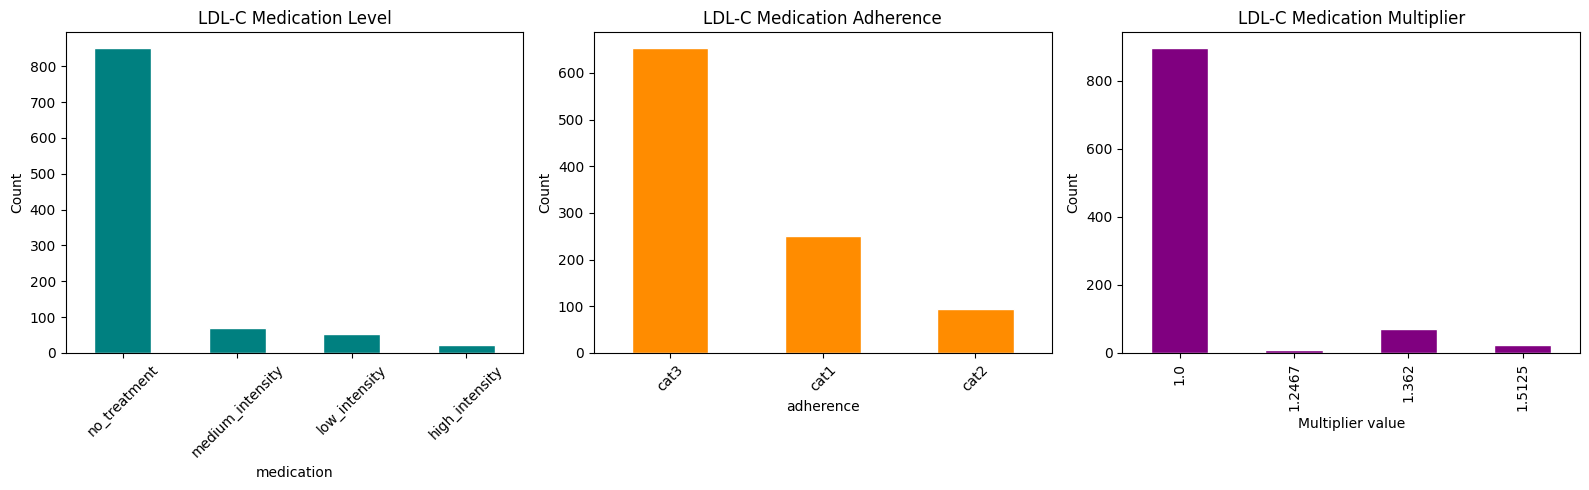


Medication x Adherence cross-tab:
adherence         cat1  cat2  cat3   All
medication                              
high_intensity       0     0    23    23
low_intensity       35    11     8    54
medium_intensity     0     0    71    71
no_treatment       216    84   552   852
All                251    95   654  1000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Medication level counts
med_counts = ldlc_df['medication'].value_counts()
med_counts.plot.bar(ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('LDL-C Medication Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Adherence counts
adh_counts = ldlc_df['adherence'].value_counts()
adh_counts.plot.bar(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('LDL-C Medication Adherence')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Multiplier distribution
mult_counts = ldlc_df['multiplier'].value_counts().sort_index()
mult_counts.plot.bar(ax=axes[2], color='purple', edgecolor='white')
axes[2].set_title('LDL-C Medication Multiplier')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Multiplier value')

plt.tight_layout()
plt.show()

# Cross-tab: medication x adherence
print('\nMedication x Adherence cross-tab:')
print(pd.crosstab(ldlc_df['medication'], ldlc_df['adherence'], margins=True))

### 4.3 Medication Effect on LDL-C

Compare GBD (untreated) vs current (treated) exposure by medication
level.

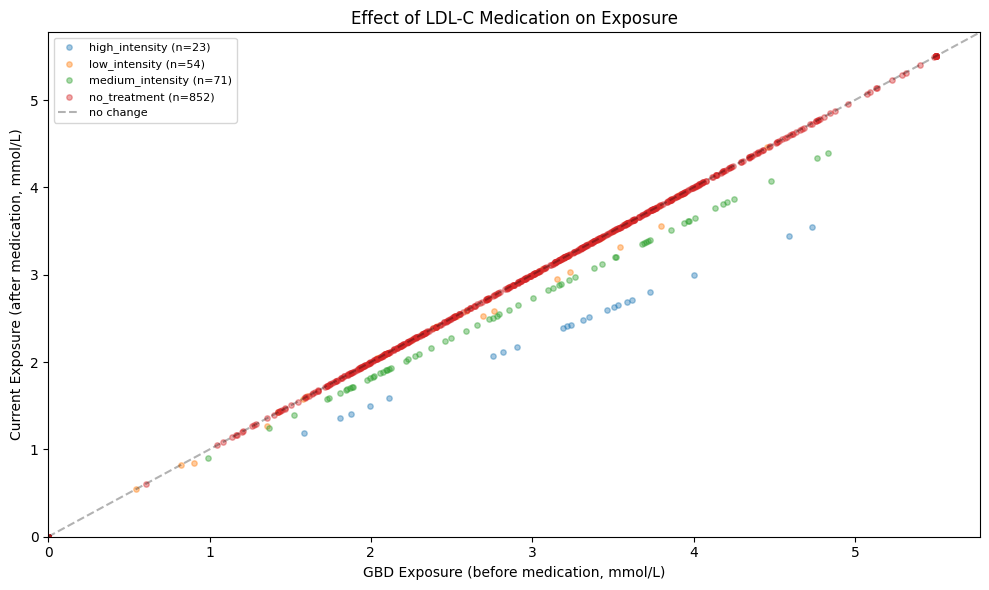

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

med_levels = ldlc_df['medication'].unique()
for i, med in enumerate(sorted(med_levels)):
    sub = ldlc_df[ldlc_df['medication'] == med]
    ax.scatter(
        sub['gbd_exposure'], sub['current_exposure'],
        alpha=0.4, s=15, label=f'{med} (n={len(sub)})',
    )

# Identity line
lims = [0, ldlc_df[['gbd_exposure', 'current_exposure']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.3, label='no change')
ax.set_xlabel('GBD Exposure (before medication, mmol/L)')
ax.set_ylabel('Current Exposure (after medication, mmol/L)')
ax.set_title('Effect of LDL-C Medication on Exposure')
ax.legend(fontsize=8)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

## 5. LDL-C Relative Risks on MI and Ischemic Stroke

The `MediatedRiskEffect` components compute relative risks for each
simulant based on their LDL-C exposure. Higher LDL-C increases the
incidence rate of acute MI and ischemic stroke.

In [11]:
# Get LDL-C relative risks from the pipelines
rr_pipelines = {
    'Acute IS Incidence': 'high_ldl_cholesterol_on_acute_ischemic_stroke.relative_risk',
    'Chronic IS Recurrence': 'high_ldl_cholesterol_on_chronic_ischemic_stroke_to_acute_ischemic_stroke.relative_risk',
    'Acute MI Incidence': 'high_ldl_cholesterol_on_acute_myocardial_infarction.relative_risk',
    'Post-MI Recurrence': 'high_ldl_cholesterol_on_post_myocardial_infarction_to_acute_myocardial_infarction.relative_risk',
}

rr_df = ldlc_df[['age', 'sex', 'current_exposure']].copy()
for name, pipeline in rr_pipelines.items():
    rr_df[name] = sim.get_value(pipeline)(idx)

print('Relative risk summary (LDL-C on MI and IS):')
print(rr_df[list(rr_pipelines.keys())].describe().round(3))

Relative risk summary (LDL-C on MI and IS):
       Acute IS Incidence  Chronic IS Recurrence  Acute MI Incidence  \
count            1000.000               1000.000            1000.000   
mean                1.678                  1.678               2.854   
std                 0.814                  0.814               2.761   
min                 1.000                  1.000               1.000   
25%                 1.000                  1.000               1.000   
50%                 1.414                  1.414               1.850   
75%                 2.048                  2.048               3.572   
max                 6.709                  6.709              25.192   

       Post-MI Recurrence  
count            1000.000  
mean                2.854  
std                 2.761  
min                 1.000  
25%                 1.000  
50%                 1.850  
75%                 3.572  
max                25.192  


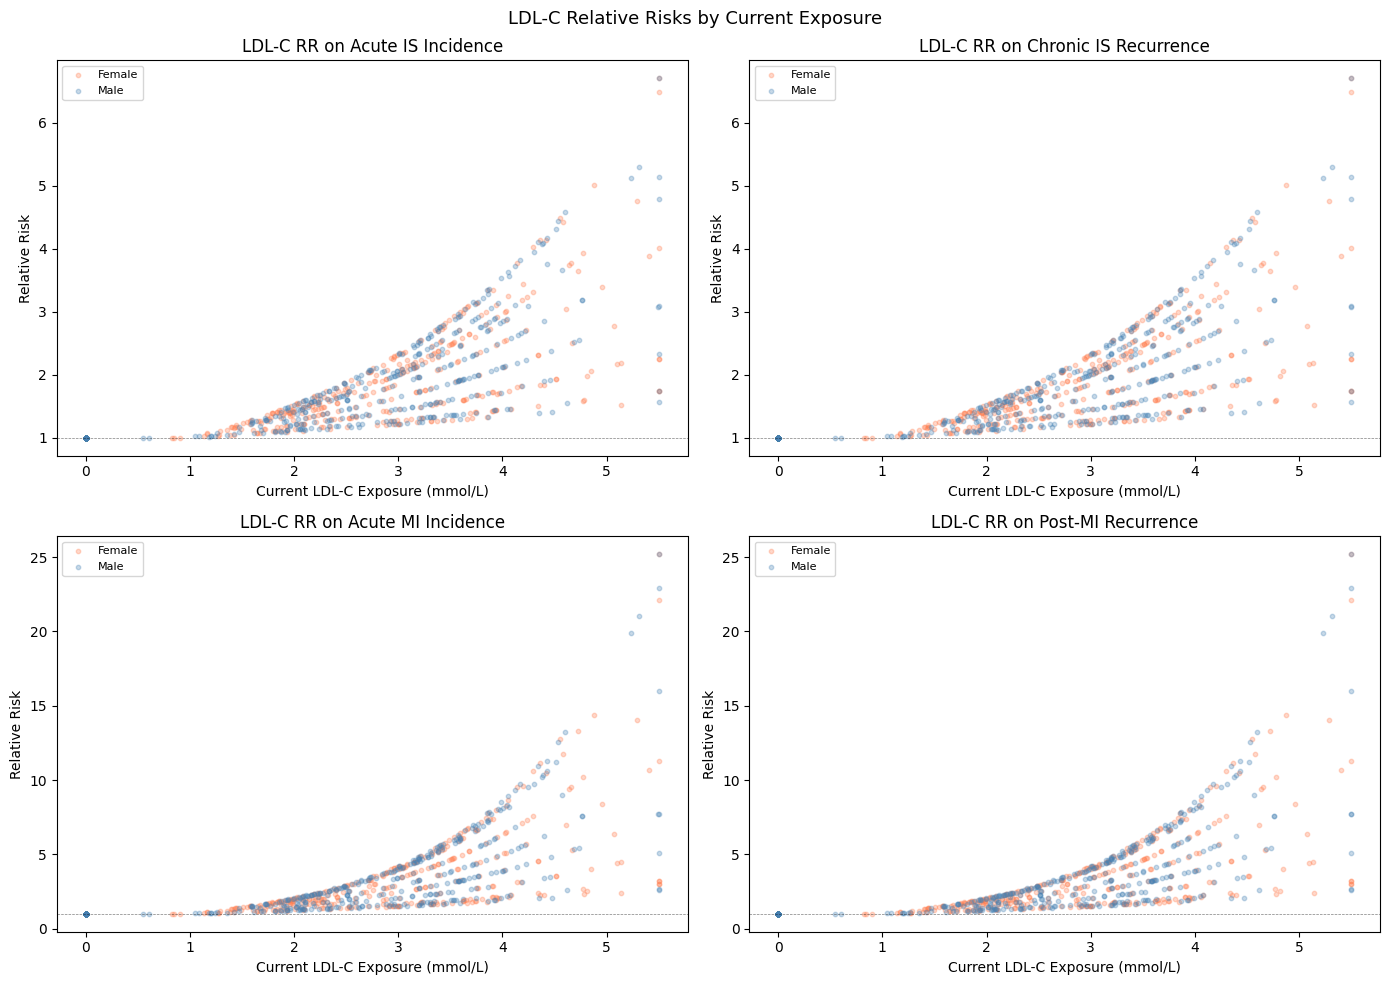

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flat, rr_pipelines.keys()):
    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        sub = rr_df[rr_df['sex'] == sex]
        ax.scatter(sub['current_exposure'], sub[name],
                   alpha=0.3, s=10, color=color, label=sex)
    ax.set_xlabel('Current LDL-C Exposure (mmol/L)')
    ax.set_ylabel('Relative Risk')
    ax.set_title(f'LDL-C RR on {name}')
    ax.axhline(1, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

plt.suptitle('LDL-C Relative Risks by Current Exposure', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Incidence Rates: MI and Ischemic Stroke

These pipelines include the full effect of all risk factors (LDL-C,
SBP, BMI, FPG) after applying PAFs and mediation.

In [13]:
rate_pipelines = {
    'Acute MI Incidence Rate': 'acute_myocardial_infarction.incidence_rate',
    'Acute IS Incidence Rate': 'acute_ischemic_stroke.incidence_rate',
    'Post-MI to Acute MI': 'post_myocardial_infarction_to_acute_myocardial_infarction.transition_rate',
    'Chronic IS to Acute IS': 'chronic_ischemic_stroke_to_acute_ischemic_stroke.transition_rate',
}

rates_df = ldlc_df[['age', 'sex', 'current_exposure']].copy()
for name, pipeline in rate_pipelines.items():
    rates_df[name] = sim.get_value(pipeline)(idx)

print('Incidence / transition rate summary (per person-year):')
print(rates_df[list(rate_pipelines.keys())].describe().round(6))

Incidence / transition rate summary (per person-year):
       Acute MI Incidence Rate  Acute IS Incidence Rate  Post-MI to Acute MI  \
count              1000.000000              1000.000000          1000.000000   
mean                  0.000296                 0.000087             0.000296   
std                   0.000729                 0.000233             0.000729   
min                   0.000000                 0.000000             0.000000   
25%                   0.000008                 0.000003             0.000008   
50%                   0.000039                 0.000016             0.000039   
75%                   0.000235                 0.000067             0.000235   
max                   0.009847                 0.002936             0.009847   

       Chronic IS to Acute IS  
count             1000.000000  
mean                 0.000087  
std                  0.000233  
min                  0.000000  
25%                  0.000003  
50%                  0.000016  


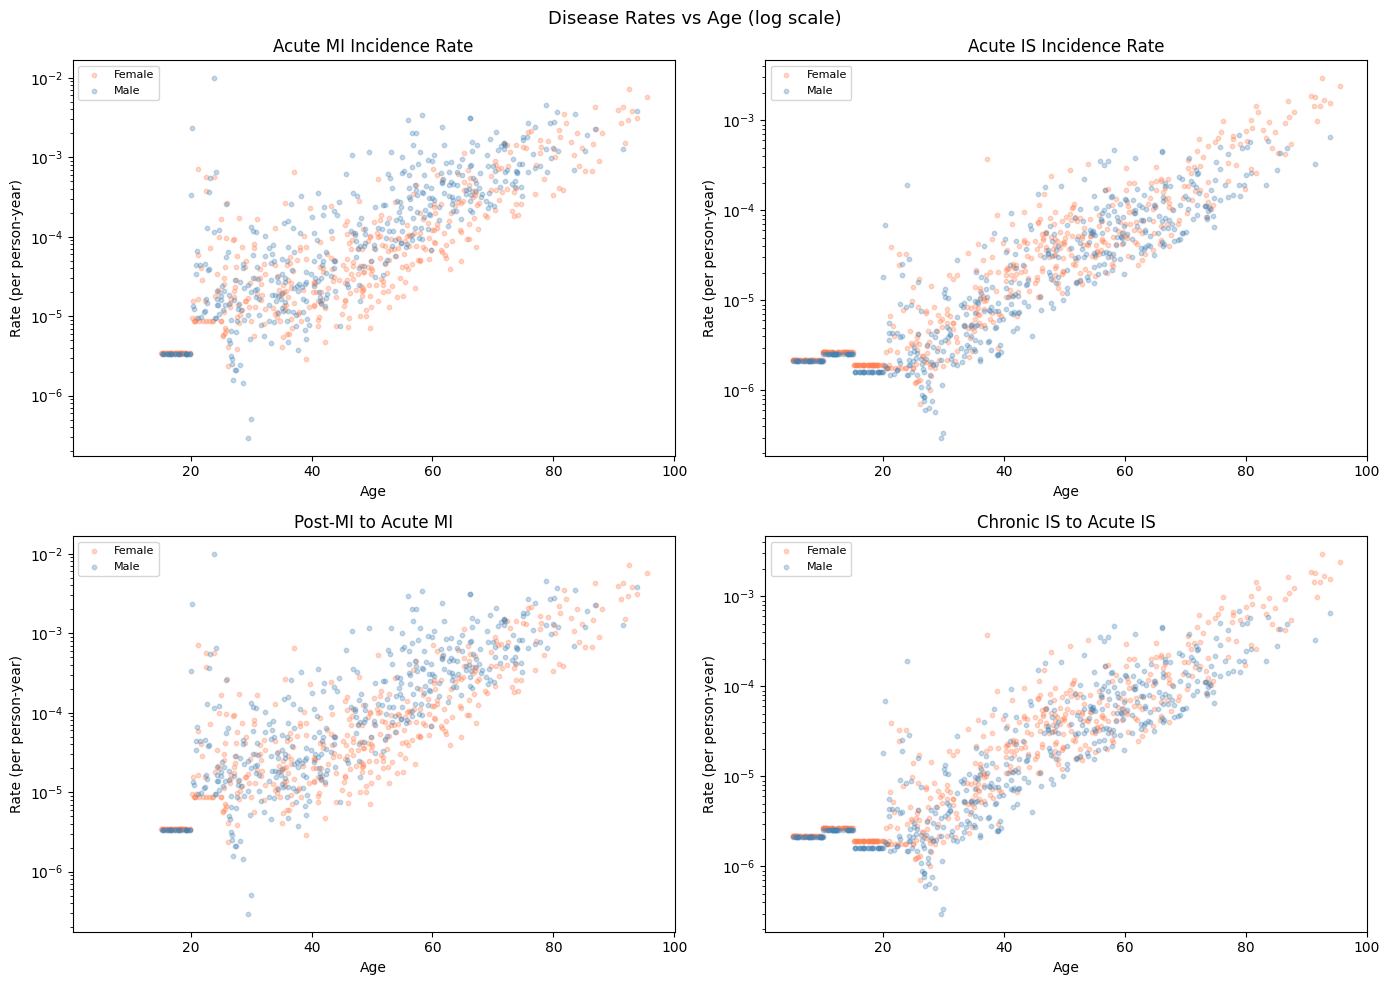

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flat, rate_pipelines.keys()):
    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        sub = rates_df[rates_df['sex'] == sex].sort_values('age')
        ax.scatter(sub['age'], sub[name], alpha=0.3, s=10, color=color, label=sex)
    ax.set_xlabel('Age')
    ax.set_ylabel('Rate (per person-year)')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.suptitle('Disease Rates vs Age (log scale)', fontsize=13)
plt.tight_layout()
plt.show()

### 6.1 Incidence Rates vs LDL-C Exposure

Show how individual incidence rates relate to LDL-C levels,
controlling for age.

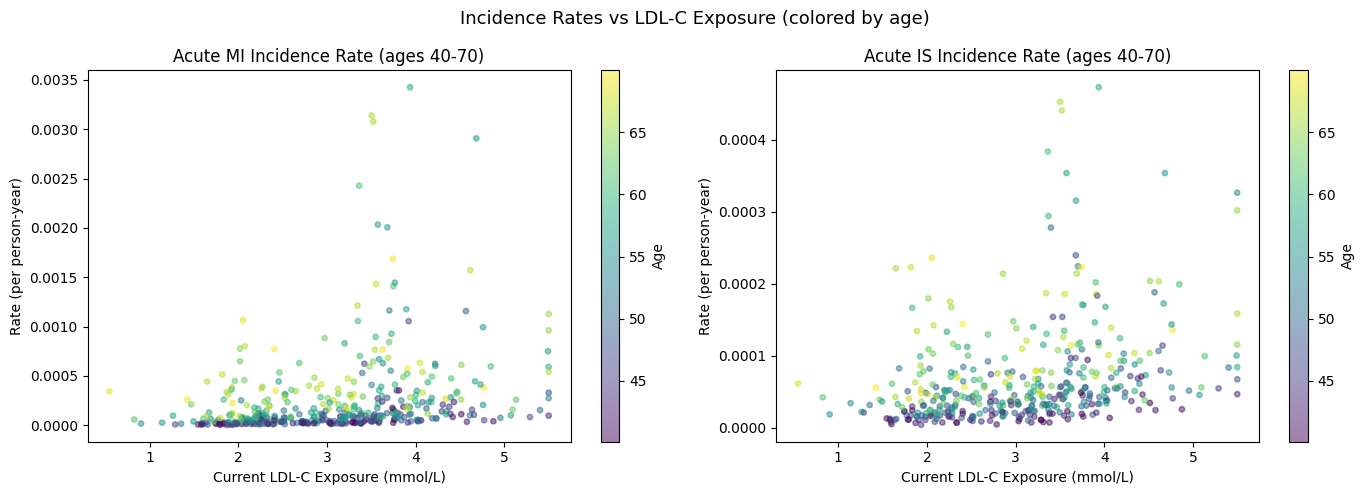

In [15]:
# Focus on adults 40-70 to reduce age confounding
mask = (rates_df['age'] >= 40) & (rates_df['age'] <= 70)
sub = rates_df[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['Acute MI Incidence Rate', 'Acute IS Incidence Rate']):
    scatter = ax.scatter(
        sub['current_exposure'], sub[name],
        c=sub['age'], cmap='viridis', alpha=0.5, s=15,
    )
    ax.set_xlabel('Current LDL-C Exposure (mmol/L)')
    ax.set_ylabel('Rate (per person-year)')
    ax.set_title(f'{name} (ages 40-70)')
    plt.colorbar(scatter, ax=ax, label='Age')

plt.suptitle('Incidence Rates vs LDL-C Exposure (colored by age)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Step the Simulation Forward

Run 13 time steps (~1 year with 28-day steps) and observe how the
population evolves.

In [16]:
# Record initial state
pop_t0 = sim.get_population()
ldlc_t0 = sim.get_value('high_ldl_cholesterol.exposure')(pop_t0.index)
print(f'Time before stepping: {sim.current_time}')

# Step 1 year
sim.take_steps(13)

pop_t1 = sim.get_population()
ldlc_t1 = sim.get_value('high_ldl_cholesterol.exposure')(pop_t1.index)
print(f'Time after stepping:  {sim.current_time}')
print(f'\nAlive at t0: {(pop_t0["alive"] == "alive").sum()}')
print(f'Alive at t1: {(pop_t1["alive"] == "alive").sum()}')
print(f'Deaths:      {(pop_t1["alive"] == "dead").sum()}')

Time before stepping: 2021-01-01 00:00:00


Time after stepping:  2021-12-31 00:00:00

Alive at t0: 1000
Alive at t1: 990
Deaths:      10


### 7.1 Disease Events in the First Year

In [17]:
event_cols = [
    'acute_ischemic_stroke_event_count',
    'acute_myocardial_infarction_event_count',
    'heart_failure_from_ischemic_heart_disease_event_count',
    'heart_failure_residual_event_count',
]

print('Disease event counts after 1 year:')
for col in event_cols:
    n = (pop_t1[col] > 0).sum()
    total = pop_t1[col].sum()
    label = col.replace('_event_count', '').replace('_', ' ')
    print(f'  {label:50s}: {n:4d} simulants ({total} total events)')

# Disease state transitions
print('\nIschemic stroke states at t1:')
print(pop_t1['ischemic_stroke'].value_counts().to_string())
print('\nIHD & HF states at t1:')
print(pop_t1['ischemic_heart_disease_and_heart_failure'].value_counts().to_string())

Disease event counts after 1 year:
  acute ischemic stroke                             :    1 simulants (1 total events)
  acute myocardial infarction                       :    1 simulants (1 total events)
  heart failure from ischemic heart disease         :    4 simulants (4 total events)
  heart failure residual                            :    2 simulants (2 total events)

Ischemic stroke states at t1:
ischemic_stroke
susceptible_to_ischemic_stroke    981
chronic_ischemic_stroke            19

IHD & HF states at t1:
ischemic_heart_disease_and_heart_failure
susceptible_to_ischemic_heart_disease_and_heart_failure    962
heart_failure_from_ischemic_heart_disease                   17
post_myocardial_infarction                                  14
heart_failure_residual                                       7


### 7.2 LDL-C Changes Over the First Year

LDL-C can change if a simulant starts/changes medication. Compare
individual-level LDL-C at t0 vs t1.

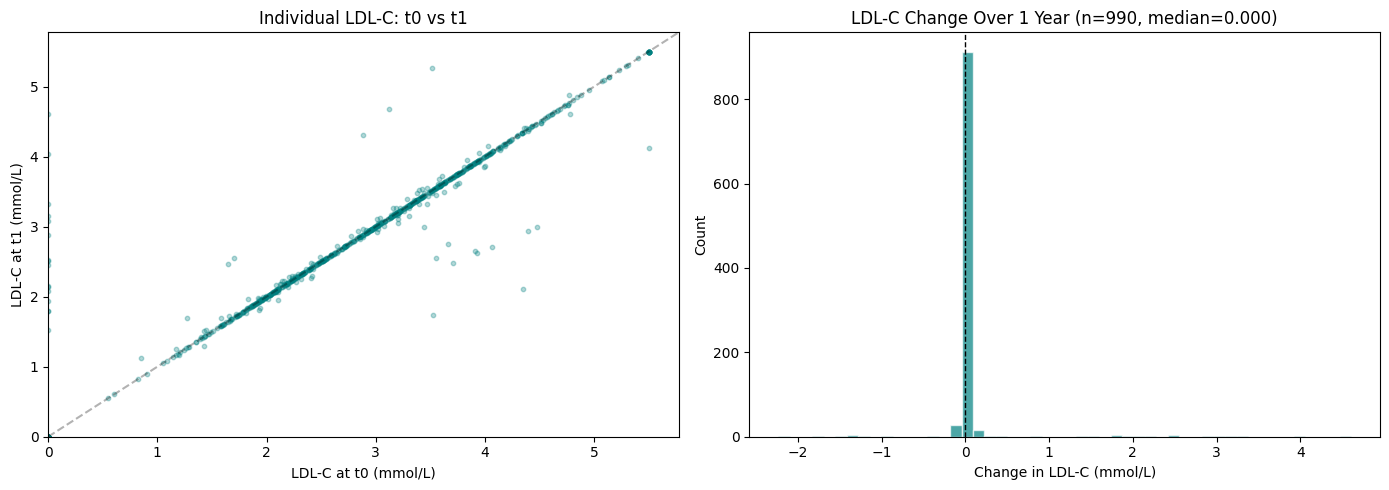

Simulants whose LDL-C medication changed: 26 / 990


In [18]:
# Only compare simulants still alive
alive_idx = pop_t1[pop_t1['alive'] == 'alive'].index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: t0 vs t1
ax = axes[0]
ax.scatter(ldlc_t0[alive_idx], ldlc_t1[alive_idx], alpha=0.3, s=10, color='teal')
lims = [0, max(ldlc_t0[alive_idx].max(), ldlc_t1[alive_idx].max()) * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('LDL-C at t0 (mmol/L)')
ax.set_ylabel('LDL-C at t1 (mmol/L)')
ax.set_title('Individual LDL-C: t0 vs t1')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Histogram of changes
ax = axes[1]
delta = ldlc_t1[alive_idx] - ldlc_t0[alive_idx]
ax.hist(delta, bins=50, color='teal', edgecolor='white', alpha=0.7)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Change in LDL-C (mmol/L)')
ax.set_ylabel('Count')
ax.set_title(f'LDL-C Change Over 1 Year (n={len(alive_idx)}, median={delta.median():.3f})')

plt.tight_layout()
plt.show()

# How many changed medication?
med_changed = pop_t0.loc[alive_idx, 'ldlc_medication'] != pop_t1.loc[alive_idx, 'ldlc_medication']
print(f'Simulants whose LDL-C medication changed: {med_changed.sum()} / {len(alive_idx)}')

## 8. Longer Run: Track LDL-C and Events Over 3 Years

Step additional years and track aggregate statistics.

In [19]:
# We already ran 1 year. Run 2 more (so we end at year 3 total).
history = []

def record_state(sim, history):
    pop = sim.get_population()
    alive = pop[pop['alive'] == 'alive']
    ldlc = sim.get_value('high_ldl_cholesterol.exposure')(alive.index)
    history.append({
        'time': sim.current_time,
        'n_alive': len(alive),
        'n_dead': (pop['alive'] == 'dead').sum(),
        'mean_ldlc': ldlc.mean(),
        'median_ldlc': ldlc.median(),
        'p25_ldlc': ldlc.quantile(0.25),
        'p75_ldlc': ldlc.quantile(0.75),
        'ami_events': pop['acute_myocardial_infarction_event_count'].sum(),
        'stroke_events': pop['acute_ischemic_stroke_event_count'].sum(),
        'mean_age': alive['age'].mean(),
    })

record_state(sim, history)

for year in range(2):
    sim.take_steps(13)
    record_state(sim, history)
    print(f'Year {year + 2}: time={sim.current_time}, alive={history[-1]["n_alive"]}')

hist_df = pd.DataFrame(history)
hist_df

Year 2: time=2022-12-30 00:00:00, alive=983


Year 3: time=2023-12-29 00:00:00, alive=968


,time,n_alive,n_dead,mean_ldlc,median_ldlc,p25_ldlc,p75_ldlc,ami_events,stroke_events,mean_age
0,2021-12-31,990,10,2.224939,2.454988,0.000000,3.388185,1,1,42.063521
1,2022-12-30,983,17,2.256397,2.482474,0.720440,3.413156,3,1,42.798304
2,2023-12-29,968,32,2.280593,2.490714,1.169807,3.414052,4,2,43.236327


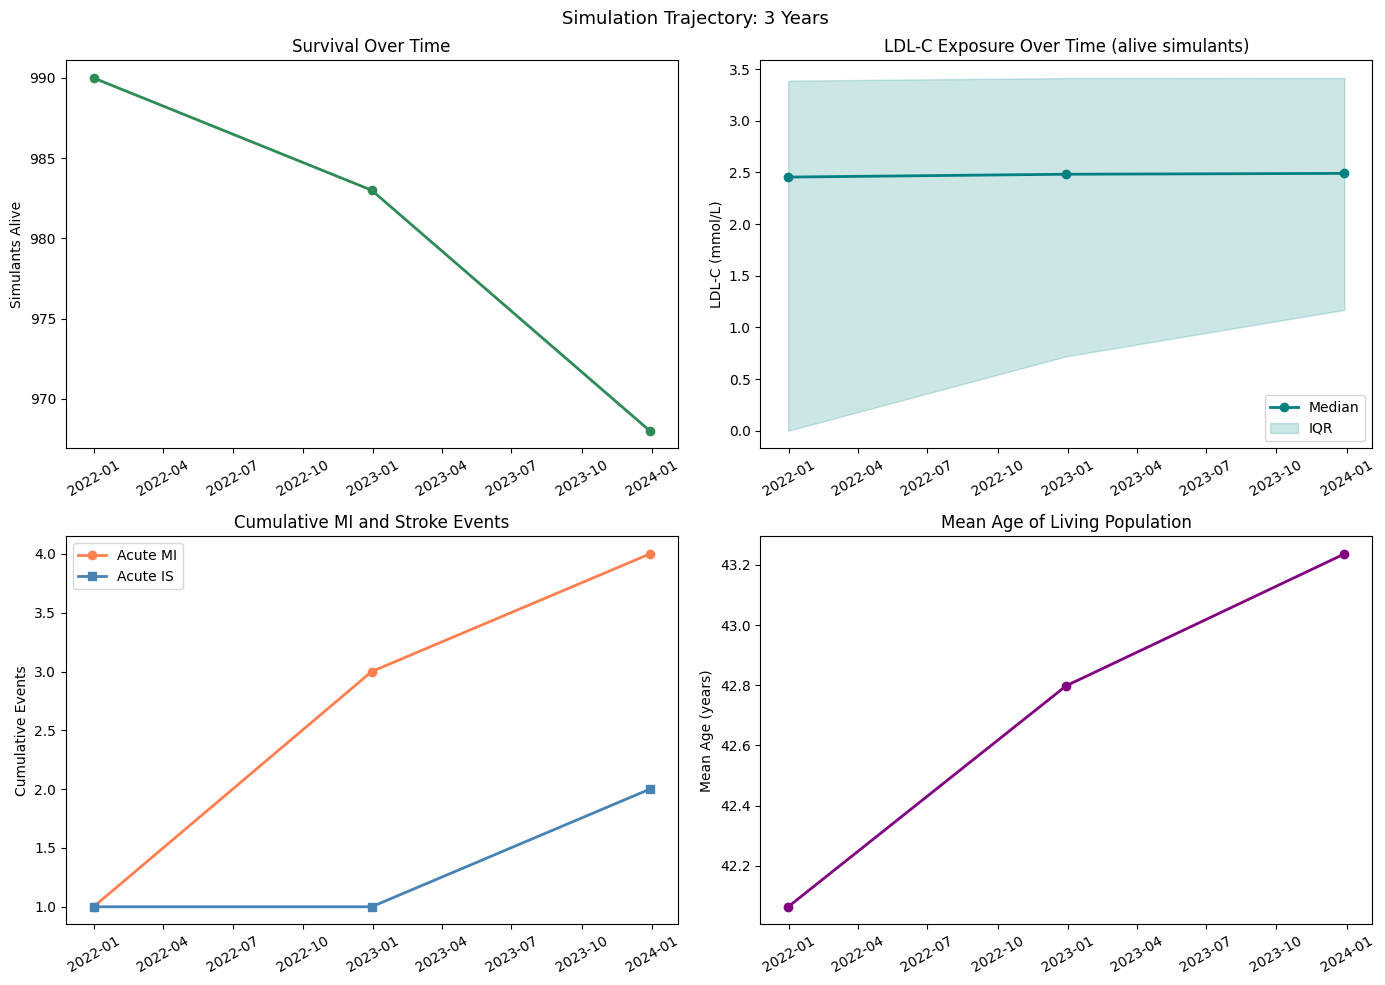

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival
ax = axes[0, 0]
ax.plot(hist_df['time'], hist_df['n_alive'], 'o-', color='seagreen', linewidth=2)
ax.set_ylabel('Simulants Alive')
ax.set_title('Survival Over Time')

# Mean LDL-C with IQR
ax = axes[0, 1]
ax.plot(hist_df['time'], hist_df['median_ldlc'], 'o-', color='teal', linewidth=2, label='Median')
ax.fill_between(hist_df['time'], hist_df['p25_ldlc'], hist_df['p75_ldlc'],
                alpha=0.2, color='teal', label='IQR')
ax.set_ylabel('LDL-C (mmol/L)')
ax.set_title('LDL-C Exposure Over Time (alive simulants)')
ax.legend()

# Cumulative events
ax = axes[1, 0]
ax.plot(hist_df['time'], hist_df['ami_events'], 'o-', color='coral', linewidth=2, label='Acute MI')
ax.plot(hist_df['time'], hist_df['stroke_events'], 's-', color='steelblue', linewidth=2, label='Acute IS')
ax.set_ylabel('Cumulative Events')
ax.set_title('Cumulative MI and Stroke Events')
ax.legend()

# Mean age of living population
ax = axes[1, 1]
ax.plot(hist_df['time'], hist_df['mean_age'], 'o-', color='purple', linewidth=2)
ax.set_ylabel('Mean Age (years)')
ax.set_title('Mean Age of Living Population')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Simulation Trajectory: 3 Years', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final Snapshot: LDL-C and Disease State Relationships

After 3 simulated years, how do LDL-C levels relate to disease
outcomes?

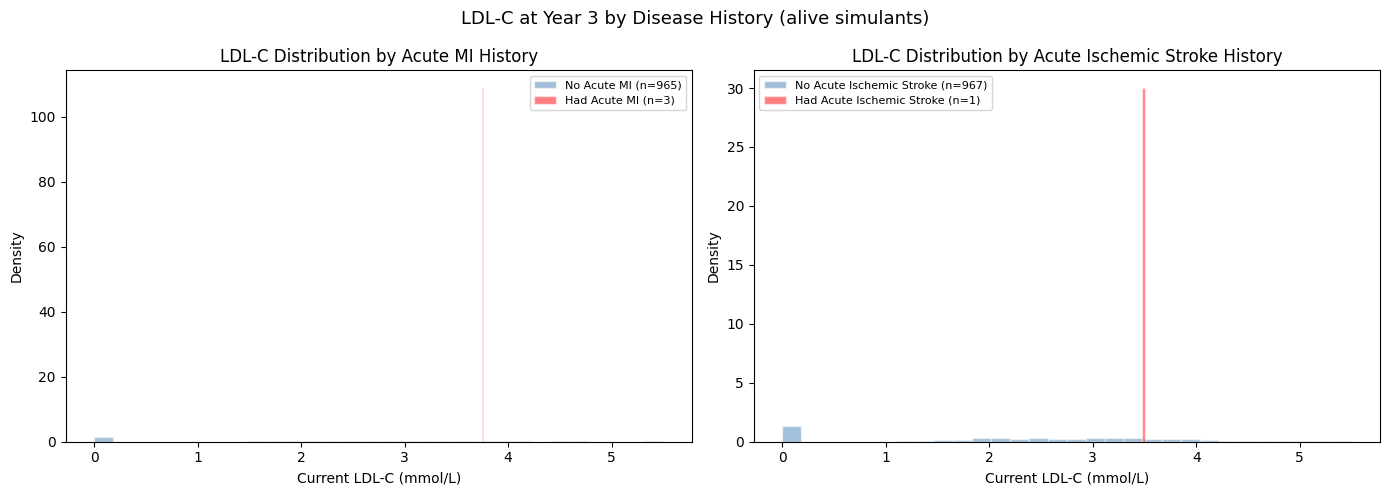

In [21]:
pop_final = sim.get_population()
alive_final = pop_final[pop_final['alive'] == 'alive'].copy()
alive_final['ldlc'] = sim.get_value('high_ldl_cholesterol.exposure')(alive_final.index)
alive_final['had_mi'] = alive_final['acute_myocardial_infarction_event_count'] > 0
alive_final['had_stroke'] = alive_final['acute_ischemic_stroke_event_count'] > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, event_col, event_name in [
    (axes[0], 'had_mi', 'Acute MI'),
    (axes[1], 'had_stroke', 'Acute Ischemic Stroke'),
]:
    for had, color, label in [(False, 'steelblue', f'No {event_name}'), (True, 'red', f'Had {event_name}')]:
        sub = alive_final[alive_final[event_col] == had]
        ax.hist(sub['ldlc'], bins=30, alpha=0.5, color=color,
                label=f'{label} (n={len(sub)})', edgecolor='white', density=True)
    ax.set_xlabel('Current LDL-C (mmol/L)')
    ax.set_ylabel('Density')
    ax.set_title(f'LDL-C Distribution by {event_name} History')
    ax.legend(fontsize=8)

plt.suptitle('LDL-C at Year 3 by Disease History (alive simulants)', fontsize=13)
plt.tight_layout()
plt.show()

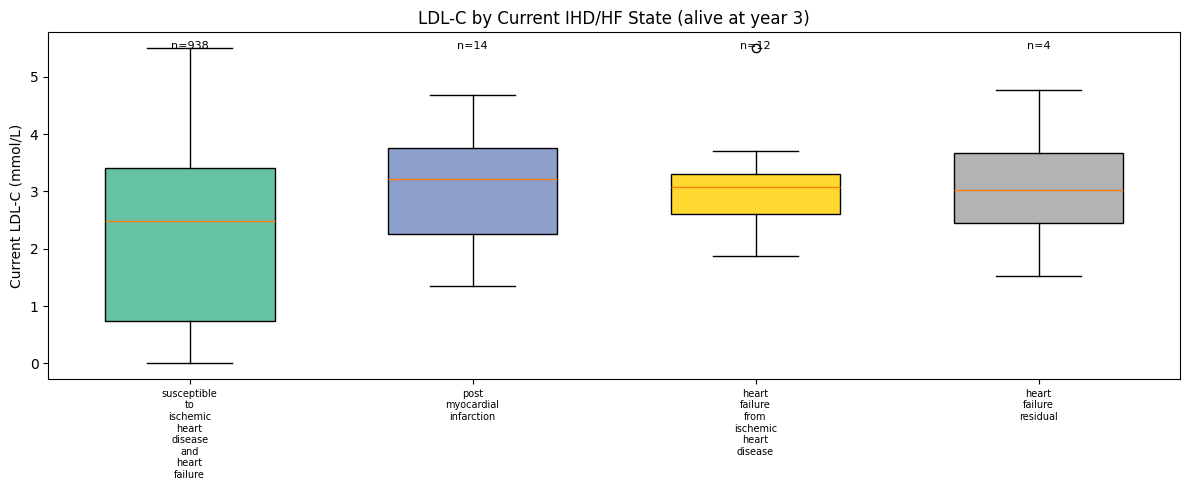

In [22]:
# LDL-C by current IHD/HF state
fig, ax = plt.subplots(figsize=(12, 5))

state_order = [
    'susceptible_to_ischemic_heart_disease_and_heart_failure',
    'acute_myocardial_infarction',
    'post_myocardial_infarction',
    'heart_failure_from_ischemic_heart_disease',
    'acute_myocardial_infarction_and_heart_failure',
    'heart_failure_residual',
]

present_states = [s for s in state_order
                  if s in alive_final['ischemic_heart_disease_and_heart_failure'].values]

box_data = [alive_final.loc[
    alive_final['ischemic_heart_disease_and_heart_failure'] == s, 'ldlc'
].values for s in present_states]

bp = ax.boxplot(box_data, labels=[s.replace('_', '\n') for s in present_states],
                patch_artist=True, widths=0.6)
colors = plt.cm.Set2(np.linspace(0, 1, len(present_states)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add sample sizes
for i, state in enumerate(present_states):
    n = (alive_final['ischemic_heart_disease_and_heart_failure'] == state).sum()
    ax.text(i + 1, ax.get_ylim()[1] * 0.95, f'n={n}', ha='center', fontsize=8)

ax.set_ylabel('Current LDL-C (mmol/L)')
ax.set_title('LDL-C by Current IHD/HF State (alive at year 3)')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

### 9.1 LDL-C at Death vs Survivors

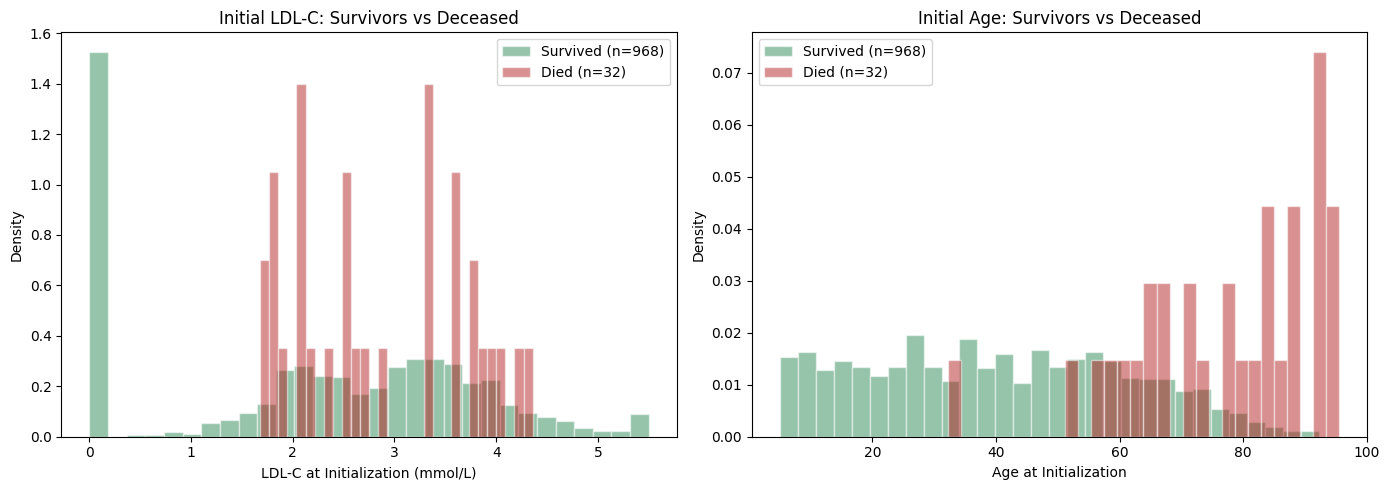

Cause of death:
cause_of_death
heart_failure_from_ischemic_heart_disease    13
heart_failure_residual                        9
other_causes                                  6
post_myocardial_infarction                    2
acute_myocardial_infarction                   1
chronic_ischemic_stroke                       1


In [23]:
# Compare LDL-C at initialization between those who died vs survived
survived = pop_final['alive'] == 'alive'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDL-C at t0
ax = axes[0]
for alive_status, color, label in [
    (True, 'seagreen', 'Survived'),
    (False, 'firebrick', 'Died'),
]:
    sub_idx = pop_final[survived == alive_status].index
    vals = ldlc_t0[sub_idx]
    ax.hist(vals, bins=30, alpha=0.5, color=color,
            label=f'{label} (n={len(sub_idx)})', edgecolor='white', density=True)
ax.set_xlabel('LDL-C at Initialization (mmol/L)')
ax.set_ylabel('Density')
ax.set_title('Initial LDL-C: Survivors vs Deceased')
ax.legend()

# Age at t0
ax = axes[1]
for alive_status, color, label in [
    (True, 'seagreen', 'Survived'),
    (False, 'firebrick', 'Died'),
]:
    sub = pop_t0[survived == alive_status]
    ax.hist(sub['age'], bins=30, alpha=0.5, color=color,
            label=f'{label} (n={len(sub)})', edgecolor='white', density=True)
ax.set_xlabel('Age at Initialization')
ax.set_ylabel('Density')
ax.set_title('Initial Age: Survivors vs Deceased')
ax.legend()

plt.tight_layout()
plt.show()

# Cause of death
dead = pop_final[pop_final['alive'] == 'dead']
print('Cause of death:')
print(dead['cause_of_death'].value_counts().to_string())

## 10. Exploring Additional Pipelines

Use `sim.list_values()` and `sim.get_value()` to explore any pipeline.
Below we show all risk factor exposures side-by-side for the surviving
population.

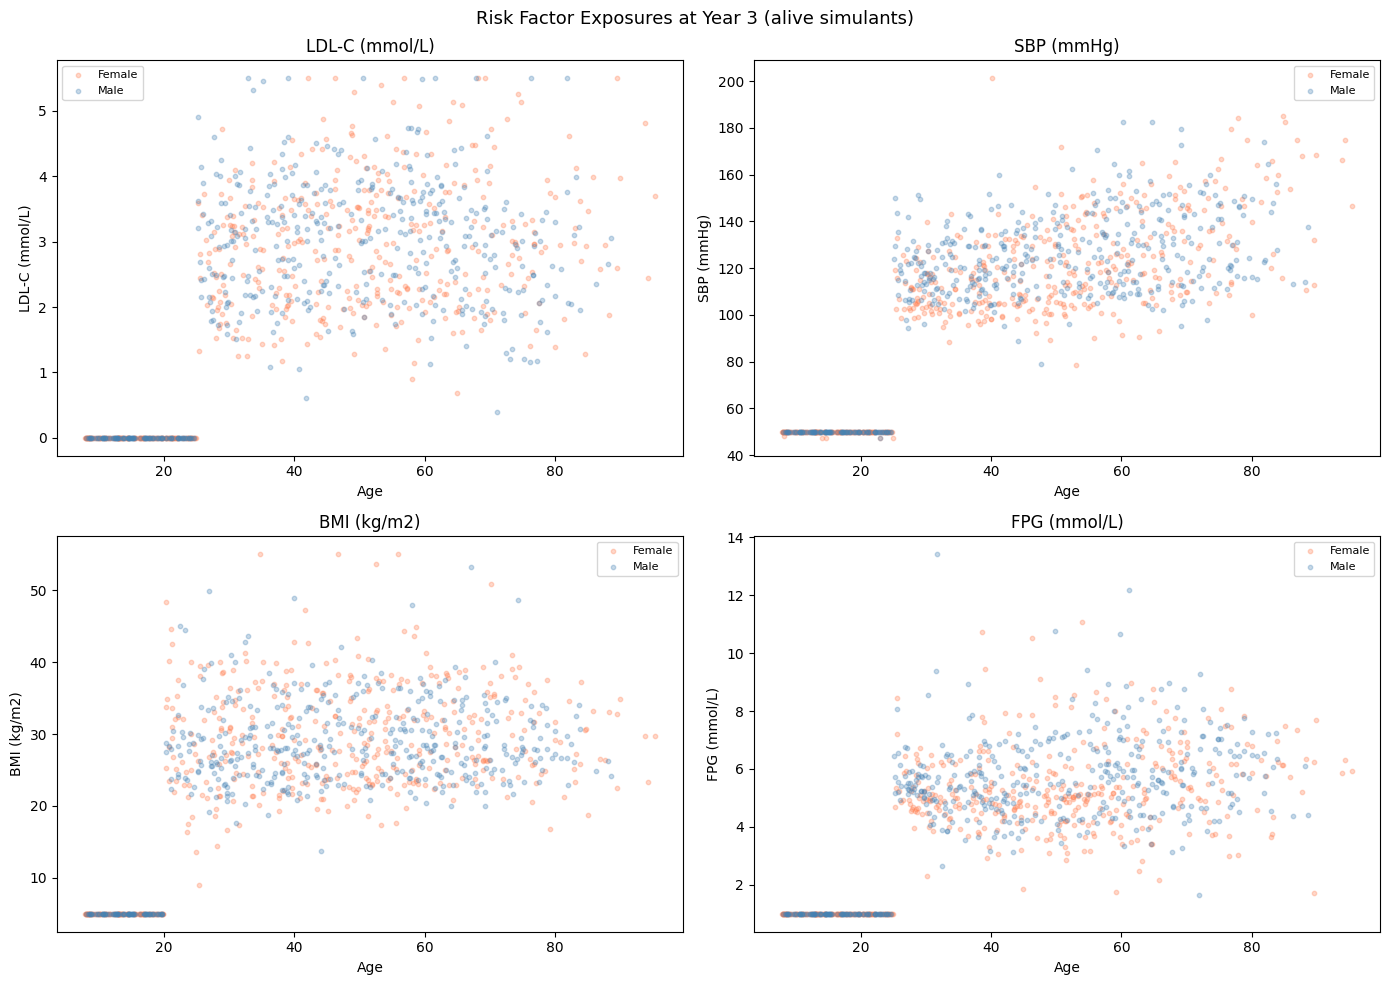

In [24]:
alive_final = pop_final[pop_final['alive'] == 'alive']
alive_idx = alive_final.index

exposure_names = {
    'LDL-C (mmol/L)': 'high_ldl_cholesterol.exposure',
    'SBP (mmHg)': 'high_systolic_blood_pressure.exposure',
    'BMI (kg/m2)': 'high_body_mass_index_in_adults.exposure',
    'FPG (mmol/L)': 'high_fasting_plasma_glucose.exposure',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, pipeline) in zip(axes.flat, exposure_names.items()):
    vals = sim.get_value(pipeline)(alive_idx)
    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        mask = alive_final['sex'] == sex
        ax.scatter(alive_final.loc[mask, 'age'], vals[mask],
                   alpha=0.3, s=10, color=color, label=sex)
    ax.set_xlabel('Age')
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Risk Factor Exposures at Year 3 (alive simulants)', fontsize=13)
plt.tight_layout()
plt.show()

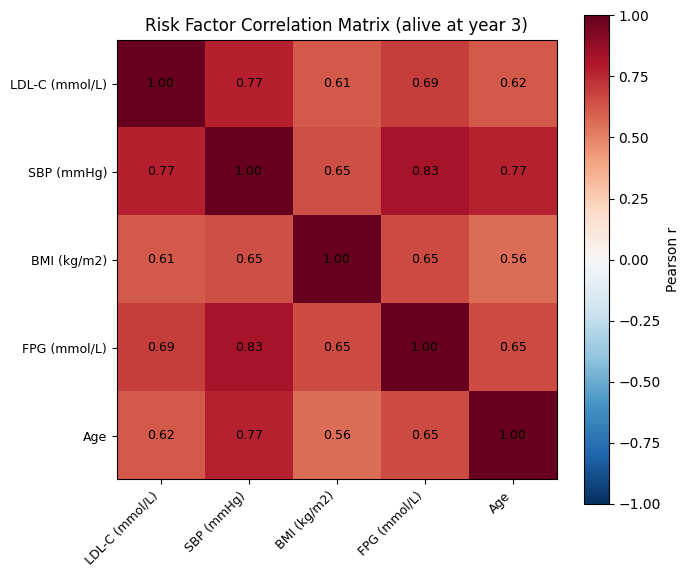

In [25]:
# Correlation between risk factors
rf_df = pd.DataFrame({name: sim.get_value(pipe)(alive_idx)
                       for name, pipe in exposure_names.items()})
rf_df['Age'] = alive_final['age'].values

corr = rf_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Risk Factor Correlation Matrix (alive at year 3)')
plt.tight_layout()
plt.show()